In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')
from src.simulate import generate_normal_data,inject_disk_degradation,inject_io_error_burst,inject_latency_spike, inject_node_failure
%matplotlib inline

In [2]:
df = generate_normal_data(n_rows=10000, seed=42)

In [3]:
df.head()

,timestamp,userDataReadIops,userDataWriteIops,readLatencyMs,writeLatencyMs,cpuPercent,memoryPercent,label
0,2026-01-01 00:00:00,4099.342831,2298.225790,2.174143,2.009714,37.640712,60.491031,0
1,2026-01-01 00:01:00,3972.356659,2354.180792,2.141662,2.472507,45.063512,59.679459,0
2,2026-01-01 00:02:00,4129.575785,2310.415687,1.531740,2.706486,39.009066,64.758954,0
3,2026-01-01 00:03:00,4304.691644,2416.614110,2.289792,3.074834,40.452846,67.664156,0
4,2026-01-01 00:04:00,3953.321630,2579.668163,1.254959,3.512081,43.586953,63.434235,0


In [4]:
used_indices = np.zeros(len(df), dtype=int)  # 0 means normal, 1-4 for anomalies
df, used_indices = inject_disk_degradation(df, used_indices,1)
df, used_indices = inject_io_error_burst(df, used_indices,4)
df, used_indices = inject_latency_spike(df, used_indices,3)
df, used_indices = inject_node_failure(df, used_indices,2)

In [5]:
df.head()

,timestamp,userDataReadIops,userDataWriteIops,readLatencyMs,writeLatencyMs,cpuPercent,memoryPercent,label
0,2026-01-01 00:00:00,4099.342831,2298.225790,2.174143,2.009714,37.640712,60.491031,0
1,2026-01-01 00:01:00,3972.356659,2354.180792,2.141662,2.472507,45.063512,59.679459,0
2,2026-01-01 00:02:00,4129.575785,2310.415687,1.531740,2.706486,39.009066,64.758954,0
3,2026-01-01 00:03:00,4304.691644,2416.614110,2.289792,3.074834,40.452846,67.664156,0
4,2026-01-01 00:04:00,3953.321630,2579.668163,1.254959,3.512081,43.586953,63.434235,0


In [6]:
df['label'].value_counts()

label
0    8208
2     510
1     500
3     477
4     305
Name: count, dtype: int64

In [7]:
df["iops_data_read_rolling_mean_5m"]=df['userDataReadIops'].rolling(window=5).mean()
df["iops_data_read_rolling_std_5m"]=df['userDataReadIops'].rolling(window=5).std()
df["iops_data_read_pct_change_1h"]=df['userDataReadIops'].pct_change(periods=60)


df["iops_data_write_rolling_mean_5m"]=df['userDataWriteIops'].rolling(window=5).mean()
df["iops_data_write_rolling_std_5m"]=df['userDataWriteIops'].rolling(window=5).std()
df["iops_data_write_pct_change_1h"]=df['userDataWriteIops'].pct_change(periods=60)


df["read_latency_rolling_mean_5m"]=df['readLatencyMs'].rolling(window=5).mean()
df["read_latency_rolling_std_5m"]=df['readLatencyMs'].rolling(window=5).std()
df["read_latency_pct_change_1h"]=df['readLatencyMs'].pct_change(periods=60)

df["write_latency_rolling_mean_5m"]=df['writeLatencyMs'].rolling(window=5).mean()
df["write_latency_rolling_std_5m"]=df['writeLatencyMs'].rolling(window=5).std()
df["write_latency_pct_change_1h"]=df['writeLatencyMs'].pct_change(periods=60)

In [8]:
df=df.dropna()

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9940 entries, 60 to 9999
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   timestamp                        9940 non-null   datetime64[ns]
 1   userDataReadIops                 9940 non-null   float64       
 2   userDataWriteIops                9940 non-null   float64       
 3   readLatencyMs                    9940 non-null   float64       
 4   writeLatencyMs                   9940 non-null   float64       
 5   cpuPercent                       9940 non-null   float64       
 6   memoryPercent                    9940 non-null   float64       
 7   label                            9940 non-null   int64         
 8   iops_data_read_rolling_mean_5m   9940 non-null   float64       
 9   iops_data_read_rolling_std_5m    9940 non-null   float64       
 10  iops_data_read_pct_change_1h     9940 non-null   float64       


Text(0.5, 1.0, 'Class Distribution')

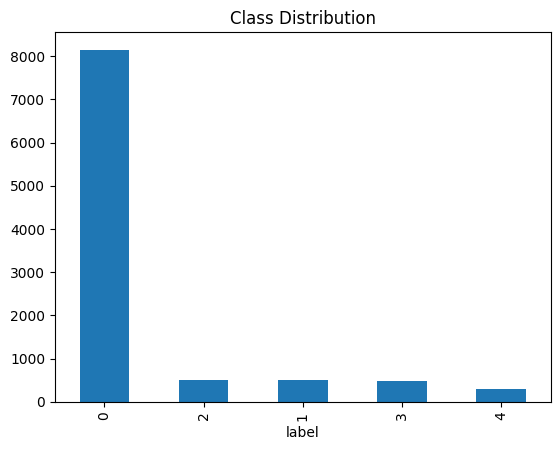

In [10]:
df['label'].value_counts().plot(kind='bar')
plt.title('Class Distribution')

In [17]:
df['group'] = (df['label'] != df['label'].shift()).cumsum()
segments = df.groupby('group').agg(
    label=('label', 'first'),
    start=('timestamp', 'first'),
    end=('timestamp', 'last')
).reset_index(drop=True)

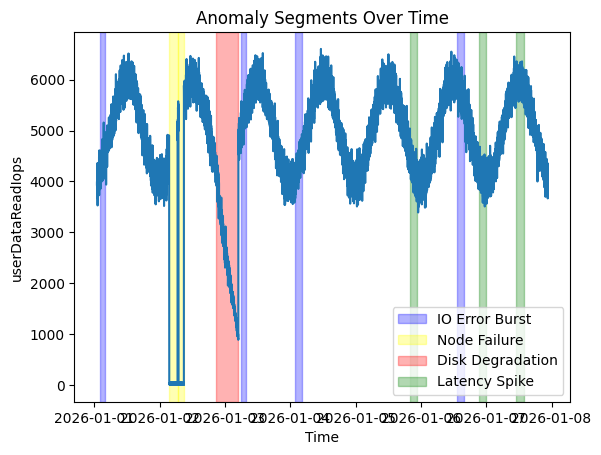

In [20]:
colors = {1: 'red', 2: 'blue', 3: 'green', 4: 'yellow'}
names = {1: 'Disk Degradation', 2: 'IO Error Burst', 3: 'Latency Spike', 4: 'Node Failure'}
labeled = set()
for _, row in segments[segments['label'] != 0].iterrows():
    lbl = row['label']
    plt.axvspan(row['start'], row['end'], color=colors[lbl], alpha=0.3,
                label=names[lbl] if lbl not in labeled else None)
    labeled.add(lbl)
plt.plot(df['timestamp'], df['userDataReadIops'])
plt.legend()
plt.title('Anomaly Segments Over Time')
plt.xlabel('Time')
plt.ylabel('userDataReadIops')
plt.show()

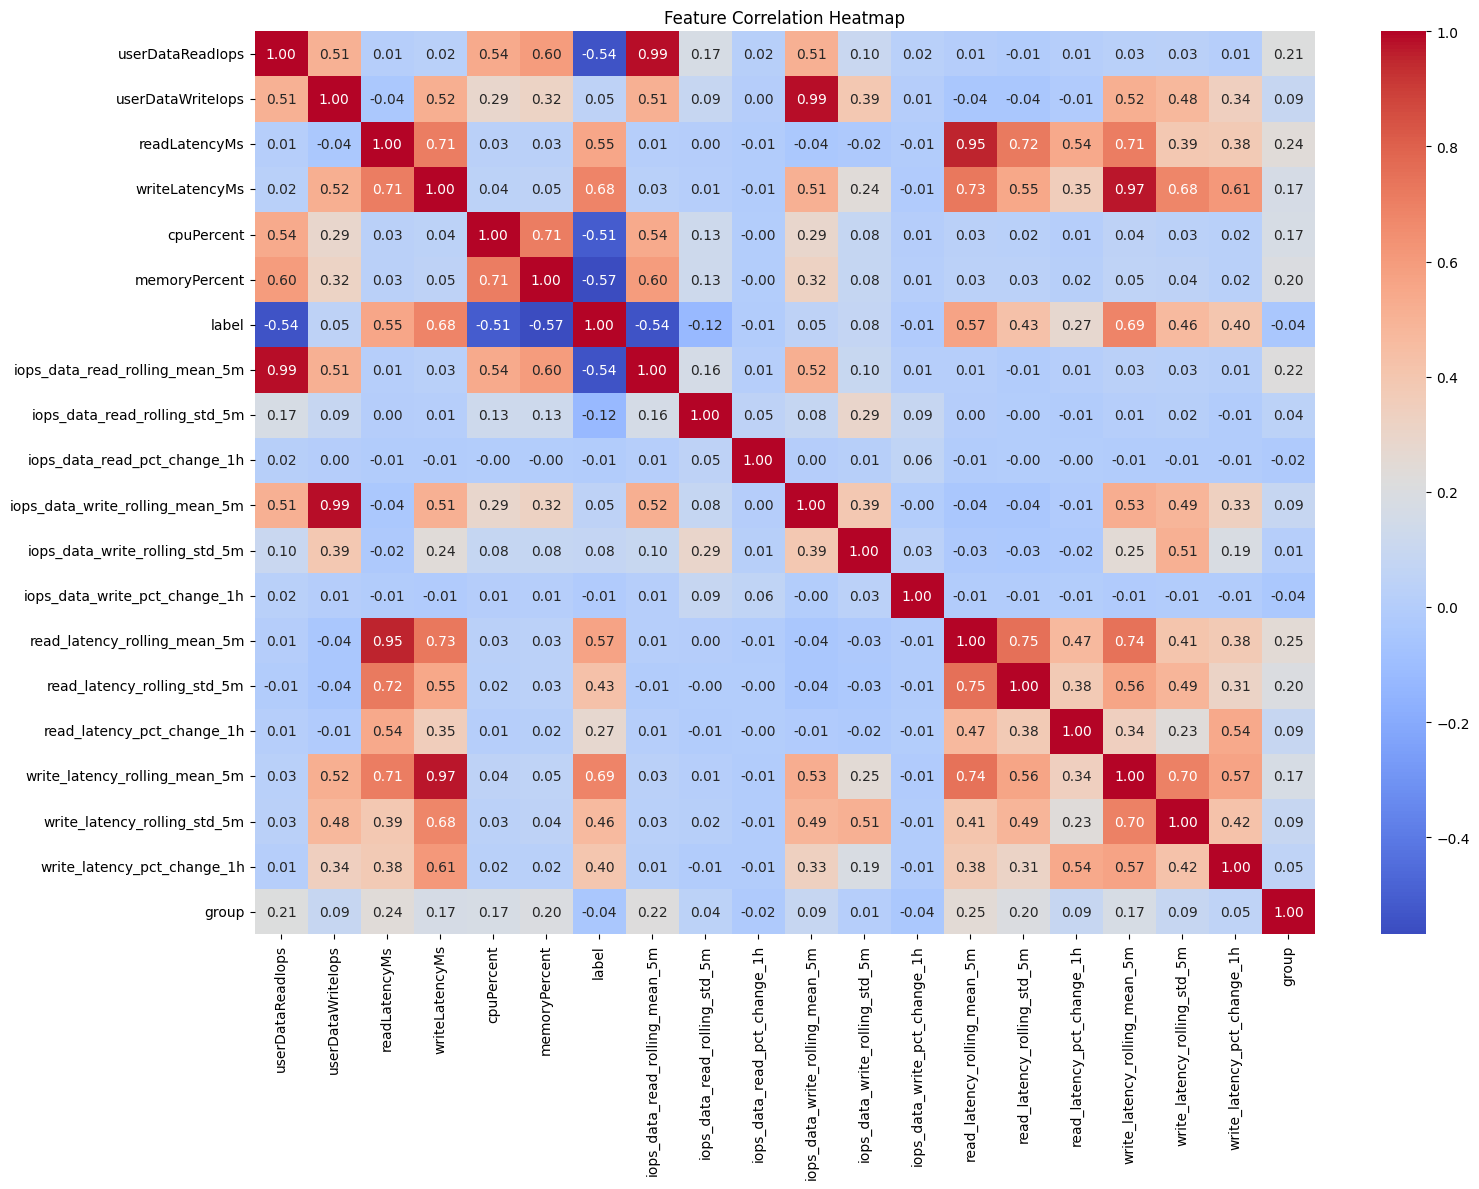

In [21]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'userDataReadIops Distribution by Label')

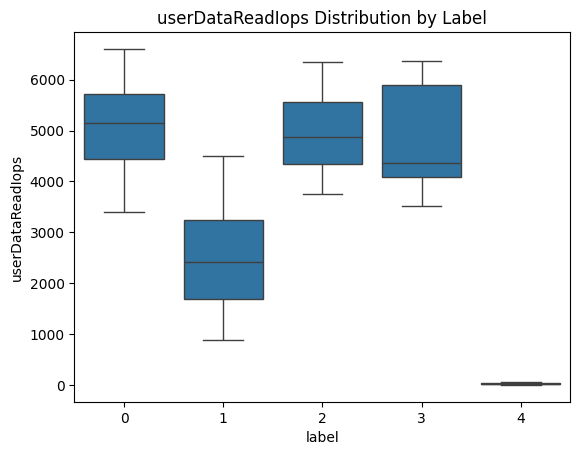

In [22]:
sns.boxplot(x='label', y='userDataReadIops', data=df)
plt.title('userDataReadIops Distribution by Label')

In [23]:
df.to_csv('../data/simulated_data_final.csv', index=False)